In [1]:
import os, sys
os.chdir(os.path.dirname(sys.prefix))
# print(f"Рабочая директория: {os.getcwd()}")

In [2]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.transforms import v2

import os
import matplotlib.pyplot as plt
import numpy as np

import json
from tqdm import tqdm
from PIL import Image

In [3]:
from src.tsp_dewarp.dataset import TPSDataset

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [5]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((256, 256))
])

In [6]:
DATASET_FOLDER = 'data/generated/v3/'
dataset = TPSDataset(DATASET_FOLDER, transform=transform)
len(dataset)

1500

In [11]:
train_data, val_data, test_data = random_split(dataset, [0.7, 0.1, 0.2])
len(train_data), len(val_data), len(test_data)

(1050, 150, 300)

In [12]:
BATCH_SIZE=32
train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, BATCH_SIZE, shuffle=False)

In [38]:
import torch
import torch.nn as nn
import torchvision.models as models

class TPSRegressor(nn.Module):
    def __init__(self, num_points=20):
        super().__init__()

        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Identity()

        self.backbone.conv1 = nn.Conv2d(
            1, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.regressor = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_points * 2)
        )

    def forward(self, x):
        features = self.backbone(x)
        delta = self.regressor(features)
        return delta


In [ ]:
model = TPSRegressor(num_points=49).to(device)
model

TPSRegressor(
  (backbone): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [41]:
x = train_data[1][0]
x = x.unsqueeze(0)
out = model(x)
out.shape

torch.Size([1, 98])

In [42]:
class TPSPointDistanceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        B = pred.shape[0]

        pred = pred.view(B, -1, 2)
        target = target.view(B, -1, 2)

        # евклидово расстояние
        dist = torch.norm(pred - target, dim=2)  # [B, num_points]

        return dist.mean()

In [43]:
class TPSLoss(nn.Module):
    def __init__(self, smooth_weight=0.1):
        super().__init__()
        self.smooth_weight = smooth_weight

    def forward(self, pred, target):
        if pred.dim() == 1:
            pred = pred.unsqueeze(0)
            target = target.unsqueeze(0)

        B = pred.shape[0]

        pred = pred.view(B, -1, 2)
        target = target.view(B, -1, 2)

        # основной L2
        dist = torch.norm(pred - target, dim=2).mean()

        # smoothness (соседние точки)
        smooth = torch.norm(pred[:, 1:] - pred[:, :-1], dim=2).mean()

        return dist + self.smooth_weight * smooth


In [44]:
# loss_model = TPSPointDistanceLoss()
loss_model = TPSLoss()
loss_model

TPSLoss()

In [45]:
y_pred = torch.tensor([[0.5, 0.25, 0.25, 0.0]])
y_true = torch.tensor([[1.0, 0.0, 0.0, 1.0]])

loss_model(y_pred, y_true).item()

0.8302520513534546

In [46]:
opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
opt

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0005
)

In [47]:
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     opt,
#     mode='min',
#     factor=0.1,
#     patience=2
# )
# scheduler

In [48]:
EPOCHS = 30

In [49]:
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    opt,
    max_lr=3e-4,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS
)
scheduler

In [51]:
CLIP_GRAD = 1.0
PATIENCE = 5

loss_model = TPSPointDistanceLoss()

train_history = []
val_history = []
lr_history = []

best_val_loss = float("inf")
early_stop_counter = 0

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()
    running_train_loss = 0.0

    train_loop = tqdm(train_loader, leave=False)

    for x, targets in train_loop:

        x = x.to(device)
        targets = targets.to(device)

        pred = model(x)
        loss = loss_model(pred, targets)

        opt.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)

        opt.step()

        running_train_loss += loss.item()

        train_loop.set_description(
            f"Epoch {epoch+1}/{EPOCHS} | loss={loss.item():.5f}"
        )

    mean_train_loss = running_train_loss / len(train_loader)

    # ================= VALID =================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for x, targets in val_loader:

            x = x.to(device)
            targets = targets.to(device)

            pred = model(x)
            loss = loss_model(pred, targets)

            running_val_loss += loss.item()

    mean_val_loss = running_val_loss / len(val_loader)

    # Scheduler step
    scheduler.step(mean_val_loss)

    current_lr = opt.param_groups[0]["lr"]

    # Сохраняем историю
    train_history.append(mean_train_loss)
    val_history.append(mean_val_loss)
    lr_history.append(current_lr)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"train_loss={mean_train_loss:.6f} | "
        f"val_loss={mean_val_loss:.6f} | "
        f"lr={current_lr:.6e}"
    )

    # ================= EARLY STOPPING =================
    if mean_val_loss < best_val_loss:
        best_val_loss = mean_val_loss
        early_stop_counter = 0
        import datetime
        save_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        torch.save(model.state_dict(), f"best_model_{save_time}.pth")
    else:
        early_stop_counter += 1

    if early_stop_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

C:\Users\trxxnk\AppData\Local\Temp\ipykernel_11820\3723485434.py:63: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(mean_val_loss)


Epoch [1/30] train_loss=0.196412 | val_loss=0.104802 | lr=1.200009e-05


Epoch [2/30] train_loss=0.082336 | val_loss=0.064868 | lr=1.200003e-05


Epoch [3/30] train_loss=0.050241 | val_loss=0.046109 | lr=1.200002e-05


Epoch [4/30] train_loss=0.040455 | val_loss=0.039466 | lr=1.200001e-05


...

Epoch [20/30] train_loss=0.019337 | val_loss=0.023914 | lr=1.200000e-05


Epoch [21/30] train_loss=0.018603 | val_loss=0.023260 | lr=1.200000e-05


Epoch [22/30] train_loss=0.018071 | val_loss=0.022979 | lr=1.200000e-05


Epoch [23/30] train_loss=0.017573 | val_loss=0.023013 | lr=1.200000e-05


KeyboardInterrupt: 

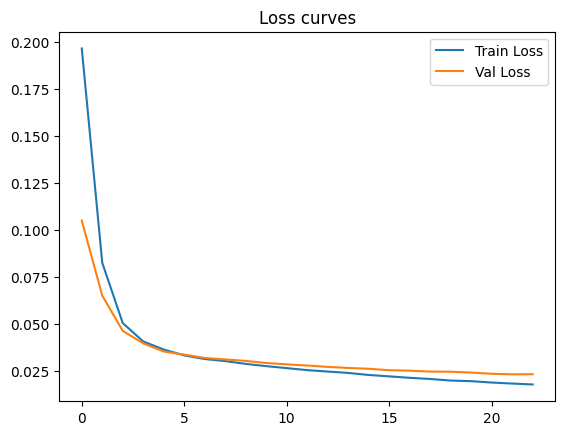

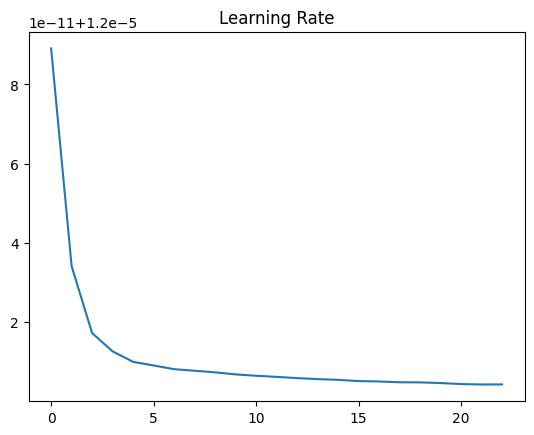

In [52]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_history, label="Train Loss")
plt.plot(val_history, label="Val Loss")
plt.legend()
plt.title("Loss curves")
plt.show()

plt.figure()
plt.plot(lr_history)
plt.title("Learning Rate")
plt.show()


Тестирование

In [26]:
import os, sys
os.chdir(os.path.dirname(sys.prefix))
# print(f"Рабочая директория: {os.getcwd()}")

In [27]:
import cv2
from src.tsp_dewarp.geometry import build_remap_from_delta_tps
from src.tsp_dewarp.dataset import TPSDataset

In [6]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.transforms import v2

import os
import matplotlib.pyplot as plt
import numpy as np

import json
from tqdm import tqdm
from PIL import Image

In [35]:
temp_state_dict = None
with open('best_model_20260221_155705.pth', 'rb') as f:
    temp_state_dict = torch.load(f)

In [36]:
temp_state_dict

OrderedDict([('backbone.conv1.weight',
              tensor([[[[ 0.0550, -0.1372,  0.1237,  ...,  0.0742,  0.0083,  0.0676],
                        [ 0.0838, -0.0792, -0.1410,  ..., -0.0229, -0.1163,  0.0702],
                        [ 0.0612,  0.1233, -0.0448,  ...,  0.0822,  0.0513,  0.0226],
                        ...,
                        [ 0.0050, -0.1306,  0.0899,  ..., -0.0569, -0.1380,  0.1364],
                        [ 0.1291, -0.0774, -0.0522,  ...,  0.1393,  0.0785,  0.0542],
                        [-0.1380, -0.0675,  0.0410,  ..., -0.1196, -0.1064, -0.0415]]],
              
              
                      [[[-0.1161,  0.0006,  0.0448,  ...,  0.0749,  0.0925,  0.1198],
                        [-0.0214, -0.0571, -0.0532,  ..., -0.0345, -0.1423, -0.0168],
                        [-0.0742, -0.0821,  0.1390,  ...,  0.0965, -0.1092,  0.1090],
                        ...,
                        [-0.0262, -0.0546,  0.0105,  ...,  0.0474, -0.1000, -0.1270],
           

In [40]:
model = TPSRegressor(num_points=49).to('cpu')
model.load_state_dict(temp_state_dict)

<All keys matched successfully>

In [41]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((256, 256))
])

In [42]:
DATASET_FOLDER = 'data/generated/v3/'
dataset = TPSDataset(DATASET_FOLDER, transform=transform)
len(dataset)

1500

In [43]:
n, k = 1, 0
idx = n + k - 1 
x_in, y_target = dataset[idx]
y_target[:6]

tensor([-0.0131, -0.0025,  0.0005, -0.0044,  0.0136, -0.0062])

In [44]:
img_path = f'data/generated/v3/latex_{n:03}_warped_{k}.png'
img_path

'data/generated/v3/latex_001_warped_0.png'

In [51]:
with open('data/generated/v3/metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f) 
y_target_2 = torch.tensor(metadata[idx]['deltaTPS'])
y_target_2[:3]

tensor([[-0.0131, -0.0025],
        [ 0.0005, -0.0044],
        [ 0.0136, -0.0062]])

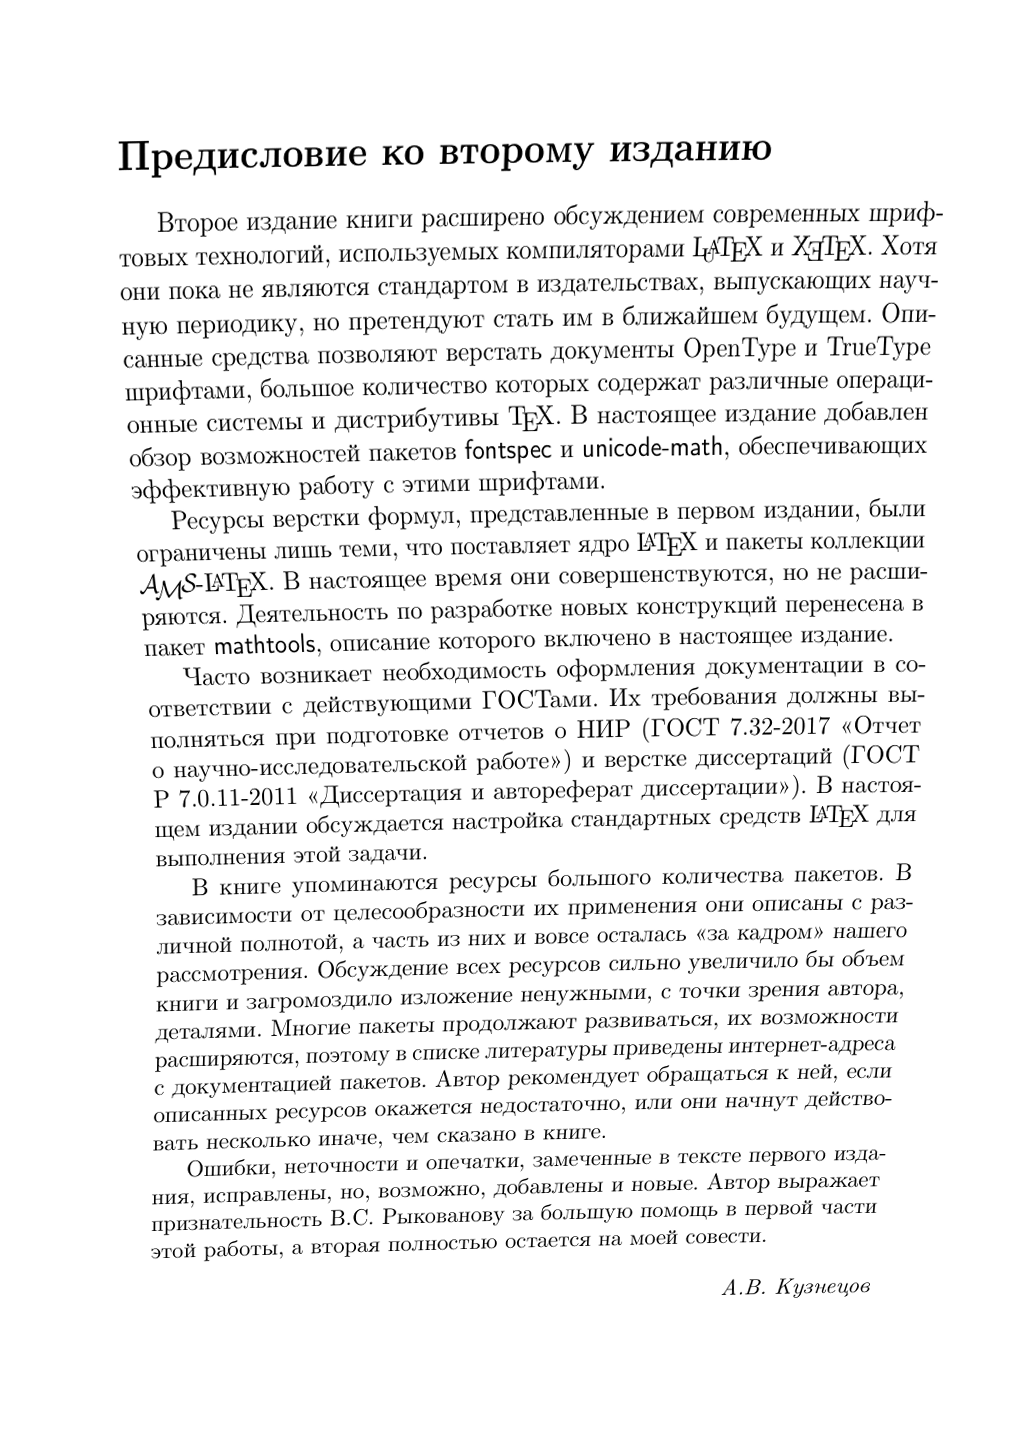

In [46]:
Image.open(img_path)

In [47]:
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1456, 1026), dtype=uint8)

In [48]:
model.eval()
y_pred = model.forward(x_in.unsqueeze(0)).reshape(49, 2).detach().numpy()
y_pred, y_pred.shape

(array([[-0.0155766 , -0.0027426 ],
        [ 0.00654735,  0.0053321 ],
        [ 0.01027417,  0.01576637],
        [ 0.01870115,  0.01518216],
        [ 0.00454317,  0.00840528],
        [-0.00858205,  0.0295391 ],
        [ 0.02955727, -0.01604559],
        [-0.00715942,  0.01752075],
        [ 0.01687977,  0.02289221],
        [ 0.02978501,  0.02822319],
        [ 0.01980112,  0.01674905],
        [ 0.01792065,  0.00877149],
        [ 0.01846225,  0.01424943],
        [ 0.00495427,  0.00699751],
        [-0.00523292,  0.01954497],
        [ 0.00632551,  0.02798236],
        [ 0.01476452,  0.00593283],
        [ 0.00242091,  0.0258099 ],
        [-0.00522515,  0.03532811],
        [ 0.01002238,  0.03391111],
        [-0.00619198,  0.00695515],
        [ 0.01109428,  0.03598868],
        [ 0.01606809,  0.02103041],
        [ 0.0264973 ,  0.04539949],
        [ 0.0365309 ,  0.0510426 ],
        [ 0.01984556,  0.03455465],
        [ 0.01867068,  0.00694726],
        [ 0.01385742,  0.006

In [24]:
img.shape[0], img.shape[1],

(943, 665)

In [52]:
# delta_tps = y_pred
map_x, map_y = build_remap_from_delta_tps(
    delta_tps=y_target_2.numpy(),  # (grid_size^2, 2)
    H=img.shape[0],
    W=img.shape[1],
    grid_size=7,
    clip=False # УБРАТЬ ОБРЕЗКУ!!!
)

rectified = cv2.remap(
    img,
    map_x,
    map_y,
    interpolation=cv2.INTER_CUBIC,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=255
)
import time
timestamp = int(time.time())
cv2.imwrite(f'data/check_v3_{n}_{k}_{timestamp}.png', rectified)

True

In [26]:
y_pred[:5]

NameError: name 'y_pred' is not defined

In [92]:
y_target

tensor([-0.0204,  0.0212, -0.0197,  0.0206, -0.0183,  0.0202, -0.0160,  0.0200,
        -0.0130,  0.0203, -0.0093,  0.0212, -0.0047,  0.0226, -0.0293,  0.0071,
        -0.0277,  0.0069, -0.0254,  0.0069, -0.0222,  0.0072, -0.0183,  0.0080,
        -0.0136,  0.0092, -0.0081,  0.0110, -0.0205, -0.0037, -0.0179, -0.0035,
        -0.0146, -0.0031, -0.0106, -0.0024, -0.0058, -0.0013, -0.0002,  0.0003,
         0.0061,  0.0024, -0.0017, -0.0114,  0.0021, -0.0108,  0.0067, -0.0101,
         0.0120, -0.0091,  0.0180, -0.0076,  0.0248, -0.0057,  0.0323, -0.0033,
         0.0033, -0.0164,  0.0089, -0.0154,  0.0152, -0.0143,  0.0222, -0.0129,
         0.0300, -0.0112,  0.0384, -0.0089,  0.0476, -0.0062, -0.0091, -0.0188,
        -0.0017, -0.0175,  0.0063, -0.0159,  0.0151, -0.0142,  0.0245, -0.0120,
         0.0346, -0.0094,  0.0455, -0.0063, -0.0191, -0.0184, -0.0104, -0.0167,
        -0.0010, -0.0148,  0.0091, -0.0127,  0.0199, -0.0101,  0.0314, -0.0072,
         0.0435, -0.0037])

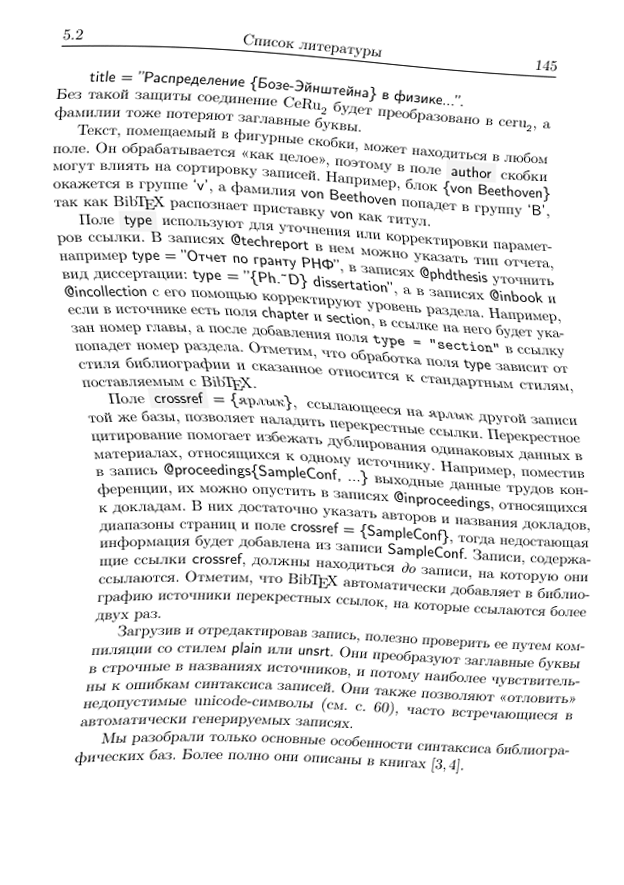

In [28]:
Image.open(r'data\check_v3_140_3_1771680366.png')